In [34]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize, curve_fit
from emcee import EnsembleSampler

import matplotlib.pyplot as plt

In [44]:
#read in data, fix columns
df = (pd.read_csv("polarizer_correlation.csv")
      .drop(columns=['Trial Number', 'Angle A'])
      .rename(columns={
          "Angle B": "ANGLE",
          "N_coin / time": "COIN_RATE",
          "TIME [s]": "TIME"
      }))
df['E_N_COIN'] = np.sqrt(df['N_COIN'])
df['E_COIN_RATE'] = df['E_N_COIN'] / df['TIME']
df

,ANGLE,N_A,N_B,N_COIN,TIME,COIN_RATE,E_N_COIN,E_COIN_RATE
0,0.0,NaN,NaN,14340,10.00077,1433.889591,119.749739,11.974052
1,22.5,NaN,NaN,13079,9.99107,1309.068999,114.363456,11.446567
2,30.0,NaN,NaN,11696,9.99126,1170.623125,108.148047,10.824265
3,45.0,NaN,NaN,8637,10.00051,863.655954,92.935461,9.293072
4,60.0,NaN,NaN,5221,9.99106,522.567175,72.256488,7.232114
5,67.5,NaN,NaN,3204,10.00011,320.396476,56.603887,5.660326
6,90.0,NaN,NaN,1333,9.98170,133.544386,36.510273,3.657721
7,100.0,NaN,NaN,1651,9.98067,165.419756,40.632499,4.071119
8,112.5,NaN,NaN,3362,10.00016,336.194621,57.982756,5.798183
9,120.0,NaN,NaN,4630,9.98259,463.807489,68.044103,6.816277


In [45]:
#plot settings
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}"
})
plt.rcParams["font.size"] = 15

In [46]:
def model(x, phase, amplitude, baseline):
    x = np.array(x)
    y = amplitude * np.cos(x * np.pi / 90 + phase * np.pi/180) + baseline
    return y

In [61]:
def redchi2(theta):
    y_mod = model(df["ANGLE"], *theta)
    y_data = df["COIN_RATE"]
    return np.sum((y_data - y_mod)**2/df['E_COIN_RATE']) / len(df - len(theta))

In [48]:
p0 = [0, 750, 750]

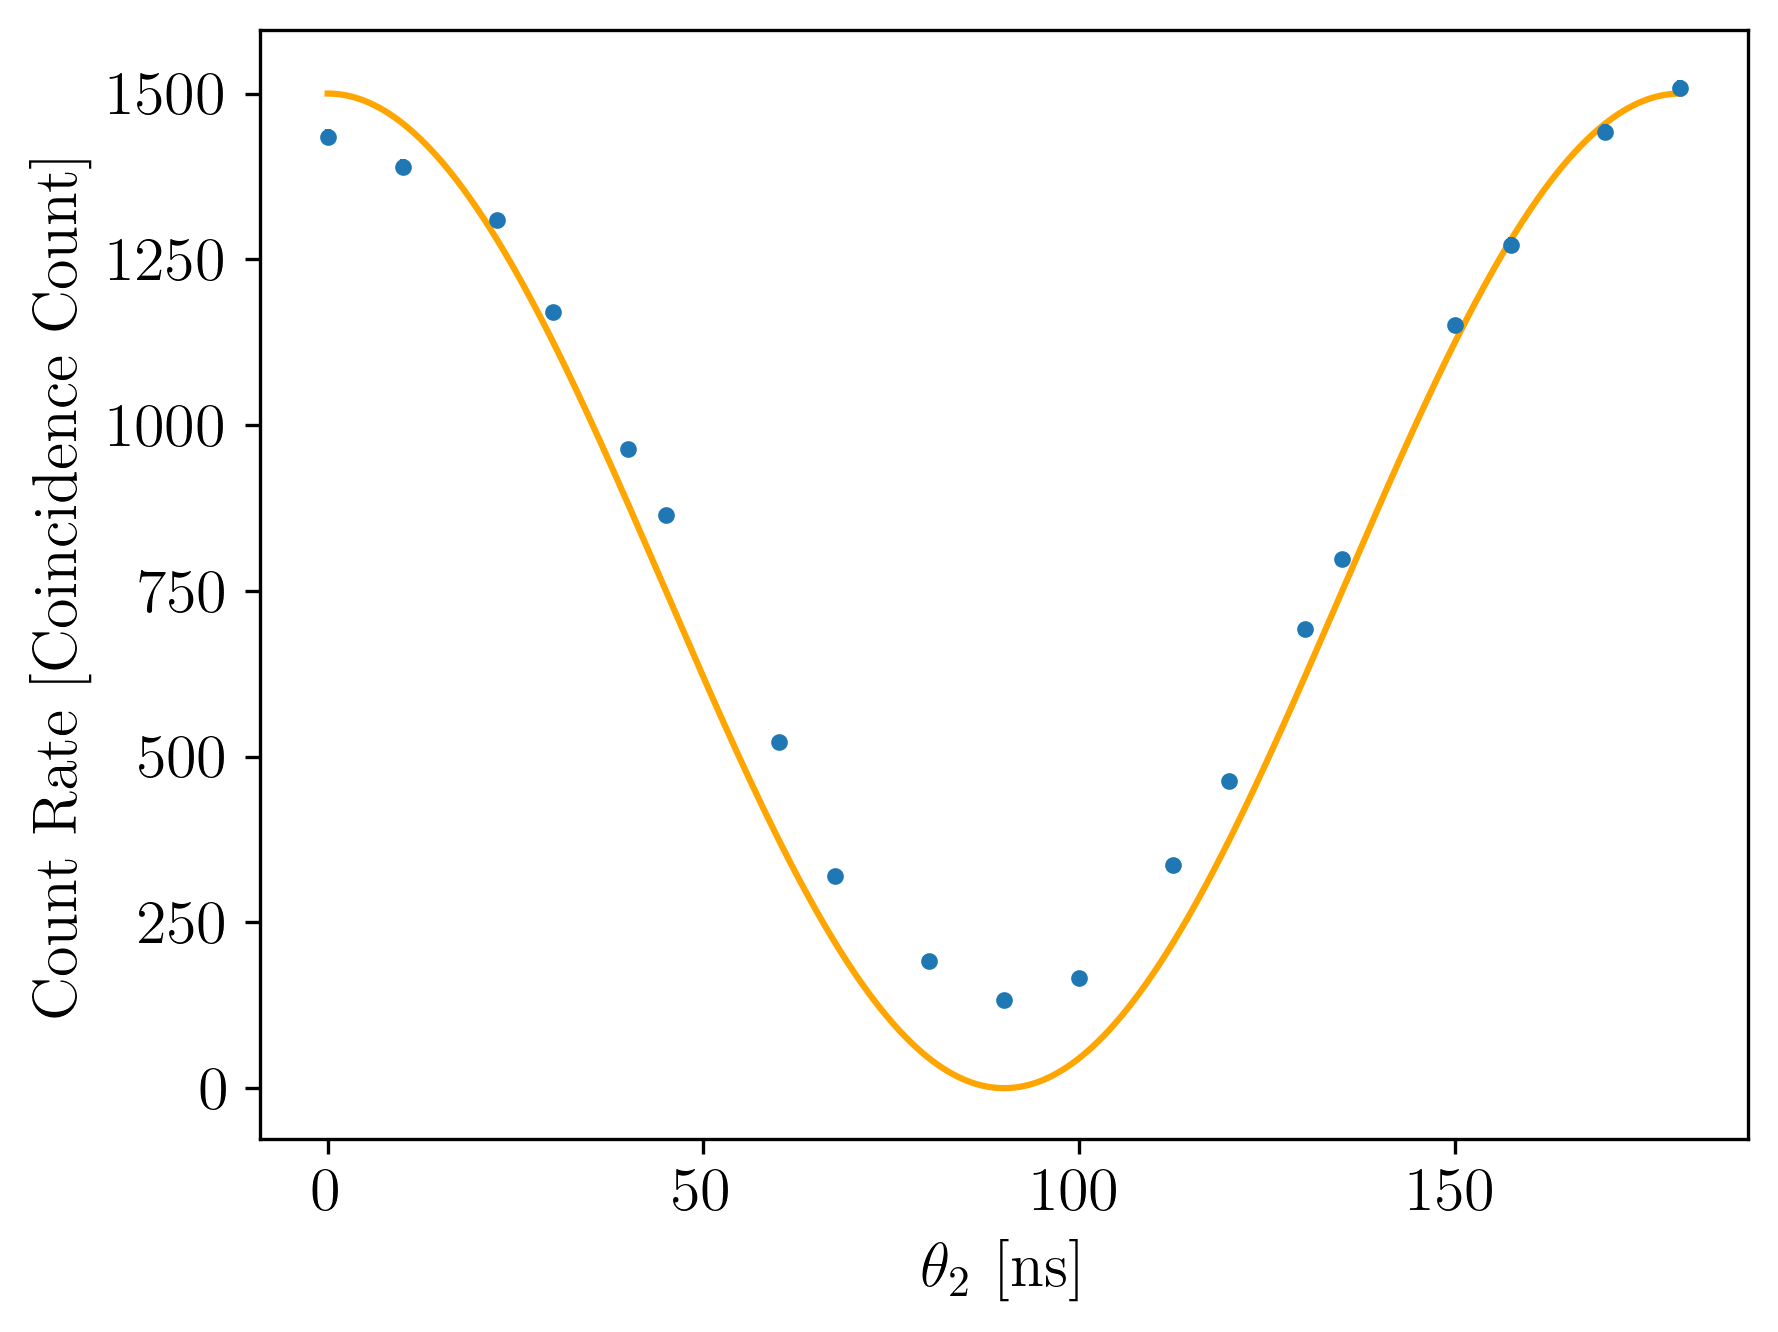

In [54]:
fig, ax = plt.subplots(dpi = 300)

x = np.linspace(0, 180, 5000)
y = model(x, *p0)
ax.plot(x, y, color = "orange")
ax.errorbar(df['ANGLE'], df['COIN_RATE'], df['E_COIN_RATE'], ls="", marker = ".")
ax.set_xlabel("$\\theta_2$ [ns]")
ax.set_ylabel("Count Rate $[\\text{Coincidence Count}]$")
plt.savefig("tau_fit.png")

In [55]:
# opt_res = minimize(lambda p: redchi2(np.exp(p)), np.log(p0), method="Nelder-Mead")
# tau_fit = np.exp(opt_res.x)[0]
# width_fit = np.exp(opt_res.x)[1]
# opt_res

In [57]:
pcurve_fit, ecurve_fit = curve_fit(model, df['ANGLE'], df['COIN_RATE'], p0)
ecurve_fit

array([[ 5.23136690e-01,  2.14937846e-01, -2.04265931e-02],
       [ 2.14937846e-01,  6.94932417e+01, -3.65980219e+00],
       [-2.04265931e-02, -3.65980219e+00,  3.51113572e+01]])

In [58]:
pcurve_fit

array([ -1.6317789 , 666.35495199, 813.7261316 ])

In [59]:
np.sqrt((np.diag(ecurve_fit)))

array([0.72328189, 8.33626065, 5.92548371])

In [63]:
redchi2(pcurve_fit)

np.float64(61.372318453977094)

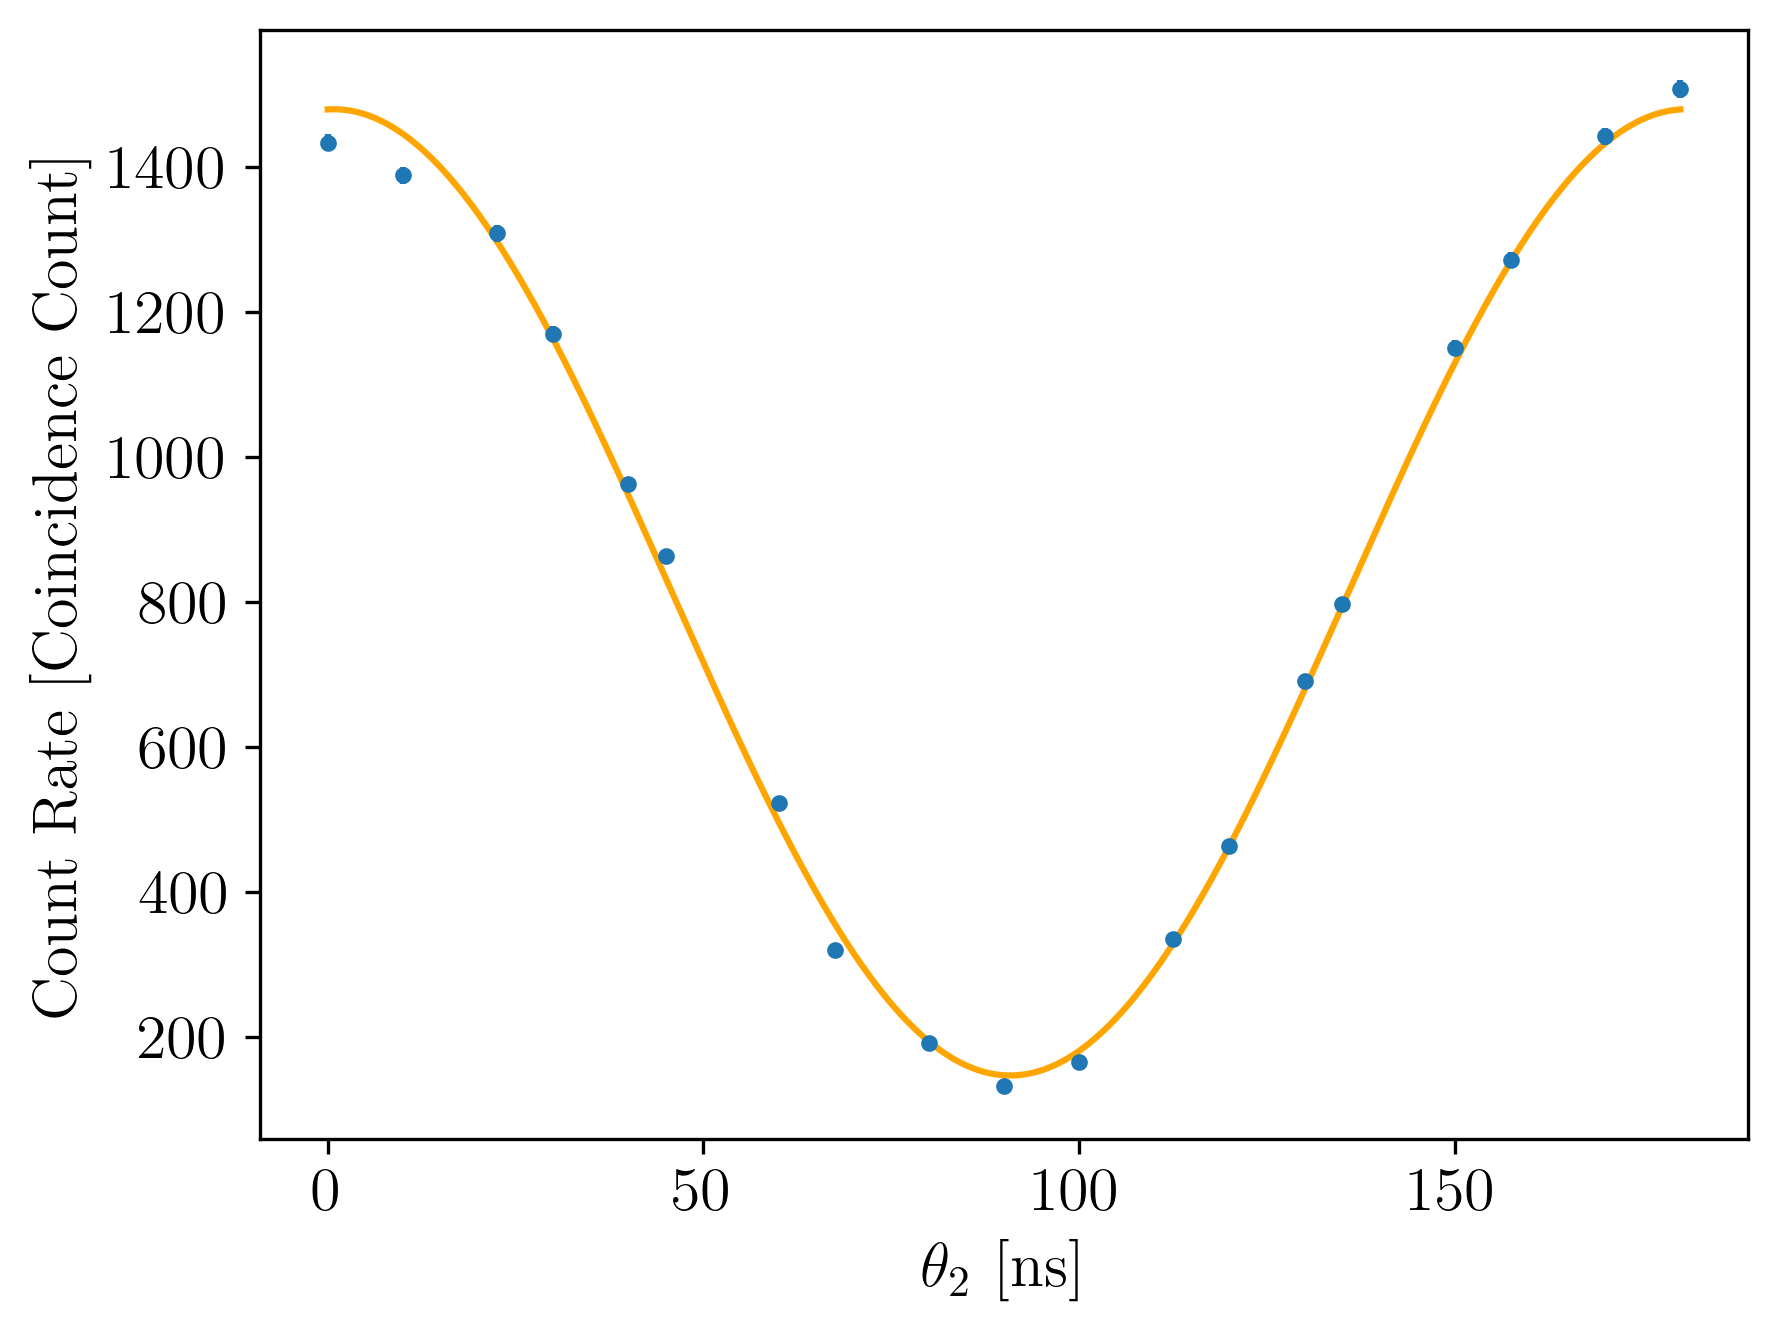

In [67]:
fig, ax = plt.subplots(dpi = 300)

x = np.linspace(0, 180, 5000)
y = model(x, *pcurve_fit)
ax.plot(x, y, color = "orange")
ax.errorbar(df['ANGLE'], df['COIN_RATE'], df['E_COIN_RATE'], ls="", marker = ".")
ax.set_xlabel("$\\theta_2$ [ns]")
ax.set_ylabel("Count Rate $[\\text{Coincidence Count}]$")
plt.savefig("tau_fit.png")

"what about uncertainties???"
# The MCMC part.

![Hypernova vs. Dying Ant](https://preview.redd.it/hypernova-vs-ant-kinda-energy-v0-0lp33c87cvdg1.jpeg?width=488&format=pjpg&auto=webp&s=14903993e0f93a18e3f39cc4ec9955249550644d)

In [71]:
#mcmc prior
def log_prior(theta):
    if np.any(theta[1:] < 0):
        return -np.inf
    return 0

#mcmc log likelihood
def log_prob(theta):
    if log_prior(theta) == -np.inf:
        return -np.inf
    
    y_mod = model(df['ANGLE'], *theta)
    y_real = df['COIN_RATE']
    return np.sum(-(y_mod - y_real)**2/df['E_COIN_RATE'])

In [72]:
#initialize mcmc walkers
N_WALKERS = 16
BUMP_SIZE = 1
x0 = pcurve_fit + BUMP_SIZE * np.random.randn(N_WALKERS, len(pcurve_fit))

In [73]:
#run mcmc
sampler = EnsembleSampler(N_WALKERS, x0.shape[1], log_prob)
sampler.run_mcmc(x0, 25_000, progress=True)

100%|██████████| 25000/25000 [02:22<00:00, 175.91it/s]


State([[ -1.70575035 670.17723281 812.7467267 ]
 [ -1.62661476 669.63277948 812.76543431]
 [ -1.5253557  670.25424574 812.77230539]
 [ -1.52742978 671.1694116  813.40296746]
 [ -1.57314442 671.25667375 812.3907844 ]
 [ -1.62800347 670.9174063  812.21198785]
 [ -1.58942704 671.80850006 812.57598413]
 [ -1.45530509 669.63002766 812.66193503]
 [ -1.69036351 670.39208659 812.48592586]
 [ -1.53667297 670.53409438 812.91916087]
 [ -1.50495906 671.88039527 812.6421162 ]
 [ -1.65753245 670.1886926  812.56938032]
 [ -1.51312436 671.3278102  812.41870744]
 [ -1.45686395 671.34737903 812.48479274]
 [ -1.49479171 670.82746939 812.56136796]
 [ -1.59236906 671.69425857 813.85823735]], log_prob=[-1133.84225716 -1132.86154554 -1131.2790417  -1132.16900413
 -1131.18884884 -1131.63860233 -1132.28550317 -1134.35807903
 -1132.89601118 -1131.01873915 -1132.91155281 -1132.05392502
 -1131.71632147 -1133.0766197  -1131.391772   -1134.34558828], blobs=None, random_state=('MT19937', array([ 480954641, 285113271

In [74]:
#names of parameters
param_labels = [
    "Phase",
    "Amplitude",
    "Baseline"
]

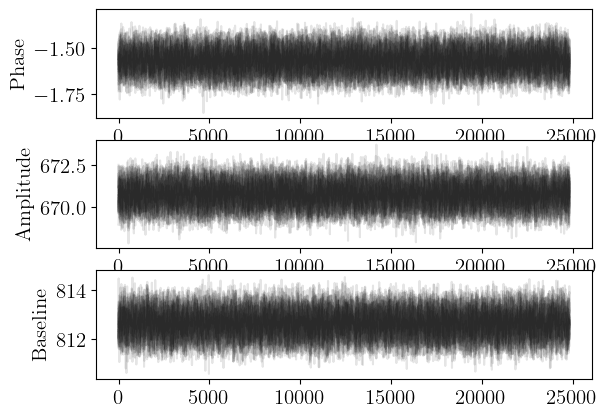

In [75]:
#check fit stability 
autocorr_time = sampler.get_autocorr_time()
chain = sampler.get_chain(discard=int(np.max(autocorr_time*4)))
for dim_n in range(chain.shape[2]):
    ax = plt.subplot(chain.shape[2], 1, dim_n + 1)
    ax.set_ylabel(param_labels[dim_n])
    for walker_n in range(chain.shape[1]):
        plt.plot(chain[:, walker_n, dim_n], c='black', alpha=0.1)

Text(0.5, 1.0, "MCMC Samples\n(Yes they're just very tight I think our uncertainties are just small...)")

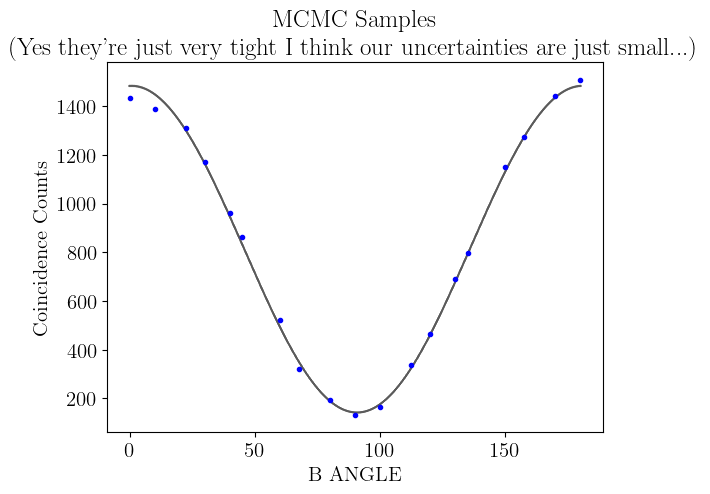

In [83]:
chain = sampler.get_chain(discard=int(np.max(autocorr_time*4)), flat=True)
ax = plt.subplot()

ax.errorbar(df['ANGLE'], df['COIN_RATE'], np.sqrt(df['E_COIN_RATE']), ls="", marker=".", c='blue')

sample_idxs = np.random.choice(chain.shape[0], 100)
# for sample_idx in range(sample_idxs):
#     ax.plot(df['ANGLE'], model(df['ANGLE'], *chain[sample_idx]))
sample_idxs

for sample_idx in sample_idxs:
    x = np.linspace(0, 180, 361)
    ax.plot(x, model(x, *chain[sample_idx]), c='black', alpha=0.008)

ax.set_xlabel("B ANGLE")
ax.set_ylabel("Coincidence Counts")
ax.set_title("MCMC Samples\n(Yes they're just very tight I think our uncertainties are just small...)")

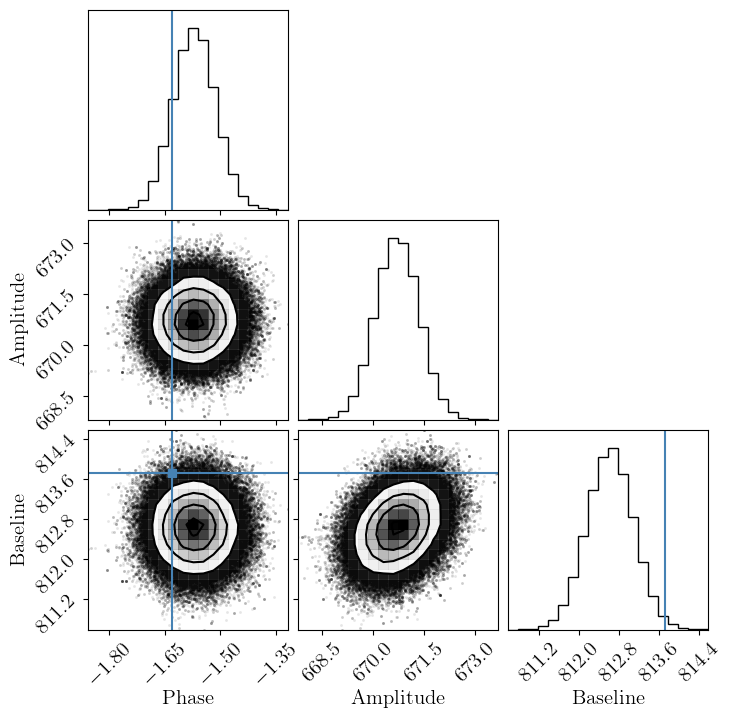

In [77]:
#examine posterior distributions of parameters
import corner
corner.corner(sampler.get_chain(discard=int(np.max(autocorr_time*4)), flat=True), labels=param_labels, truths=pcurve_fit);

In [78]:
chain = sampler.get_chain(flat=True, discard=int(np.max(autocorr_time*4)))
results = pd.DataFrame(
    {
        "Median Value": np.median(chain, axis = 0),
        "2-sigma Uncertainty": np.sqrt(np.diag(np.cov(chain.T))) * 2
    },
    index=param_labels
)
results["Uncertainty/Value"] = results["2-sigma Uncertainty"]/results["Median Value"]

In [79]:
results

,Median Value,2-sigma Uncertainty,Uncertainty/Value
Phase,-1.569543,0.113826,-0.072522
Amplitude,670.724399,1.266113,0.001888
Baseline,812.631850,0.930328,0.001145
